# RoBERTa-large — autoLRP attribution

RoBERTa-large from HuggingFace. Attributes a masked-LM prediction back to the input tokens.

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM

import autoLRP as autolrp
from autoLRP import LRPConfig
from _common import show_text_attribution

device = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ID = 'roberta-large'
MODEL_NAME = 'RoBERTa'
FILE_STEM = 'roberta'

/opt/miniconda3/envs/waleed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForMaskedLM.from_pretrained(MODEL_ID).eval().to(device)

class RobertaFromEmb(torch.nn.Module):
    """Embeddings → masked-token logits at the [MASK] position."""
    def __init__(self, m, mask_pos):
        super().__init__()
        self.encoder = m.roberta.encoder
        self.lm_head = m.lm_head
        self.mask_pos = mask_pos
    def forward(self, inputs_embeds):
        h = self.encoder(inputs_embeds).last_hidden_state
        logits = self.lm_head(h)[:, self.mask_pos, :]
        return logits

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 6510.25it/s]
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


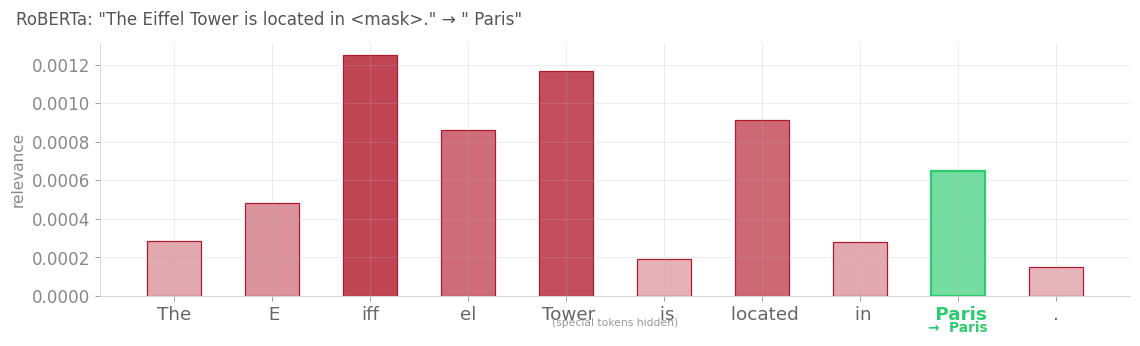

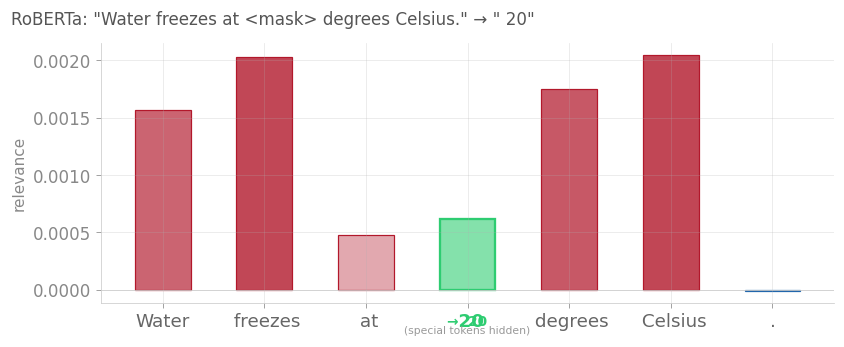

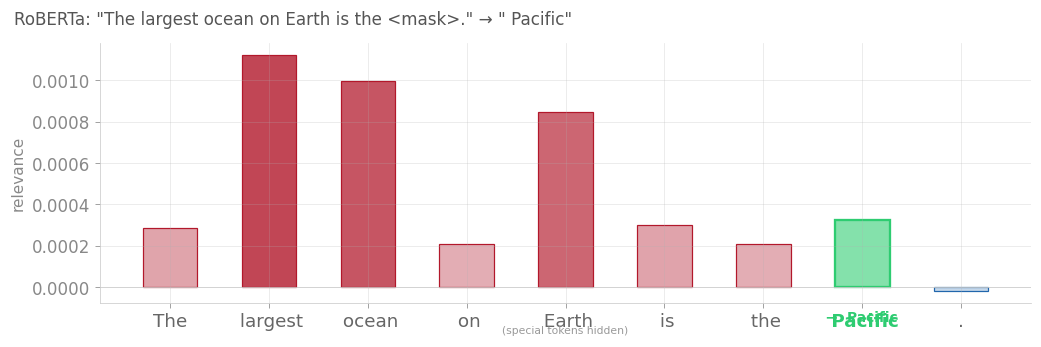

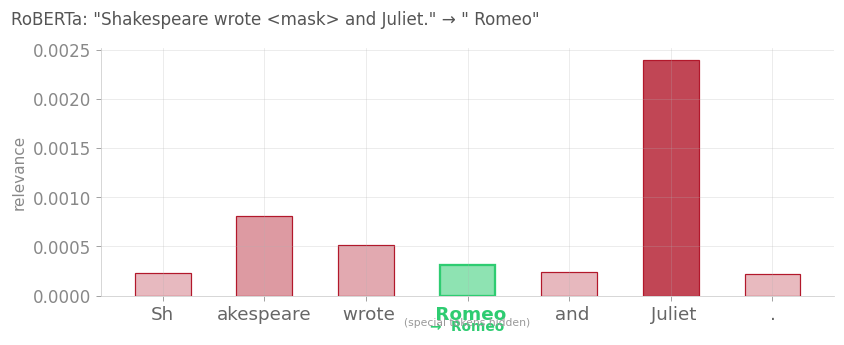

In [3]:
ROBERTA_PROMPTS = [
    f'The Eiffel Tower is located in {tok.mask_token}.',
    f'Water freezes at {tok.mask_token} degrees Celsius.',
    f'The largest ocean on Earth is the {tok.mask_token}.',
    f'Shakespeare wrote {tok.mask_token} and Juliet.',
]

for pi, text in enumerate(ROBERTA_PROMPTS):
    enc = tok(text, return_tensors='pt').to(device)
    mask_pos = (enc.input_ids[0] == tok.mask_token_id).nonzero()[0].item()

    emb = model.roberta.embeddings(enc.input_ids).detach()
    wrapper = RobertaFromEmb(model, mask_pos).eval().to(device)

    with torch.no_grad():
        pred = wrapper(emb).argmax(-1).item()
    predicted = tok.decode([pred])

    x = autolrp.tensor(emb)
    out = wrapper(x)
    out[0, pred].lrp(config=LRPConfig(attn='cplrp'))

    tokens = [t.replace('\u0120', ' ').replace('\u010a', '\\n') for t in tok.convert_ids_to_tokens(enc.input_ids[0])]
    rel = x.relevance[0].sum(-1).detach().cpu().numpy()
    show_text_attribution(tokens, rel, mask_pos=mask_pos, mask_fill=predicted,
                         prompt_text=f'{MODEL_NAME}: "{text}" \u2192 "{predicted}"')